In [1]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt  
from matplotlib.ticker import StrMethodFormatter
import seaborn as sns

# Loading Data
# dataset = load_dataset('lukebarousse/data_jobs')
# df = dataset['train'].to_pandas()

df = pd.read_csv("C:/Users/PC/Desktop/Data_Science_Project/Exporte/job_postings_flat.csv")

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [ ]:
#Set Year Filter

df_2025 = df[df["job_posted_date"].dt.year==2025]

In [13]:
#DACH data frame

DACH_countries = ["Germany","Austria","Switzerland","Luxembourg"]

df_DACH = df_2025[df_2025["job_country"].isin(DACH_countries)].copy()

In [21]:
#Top 15 Job Locations in DACH countries (incl. Luxembourg) by number of data job offerings

#Setting both Frankfurt and Frankfurt am Main to "Frankfurt a. M."
df_DACH.loc[df_DACH["job_location"].str.contains("Frankfurt", na=False, regex=False), "job_location"] = "Frankfurt a. M., Germany"

df_DACH_plot = df_DACH.groupby("job_location").size().sort_values(ascending=False).head(15).to_frame(name="count")

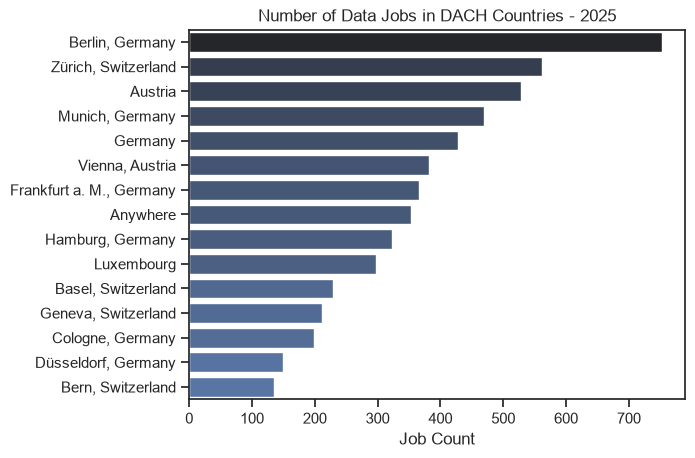

In [29]:
fig, ax = plt.subplots()

sns.set_theme(style="ticks")
sns.barplot(data=df_DACH_plot,x="count",y="job_location",hue="count",palette="dark:b_r",legend=False)

#sns.despine()
plt.title("Number of Data Jobs in DACH Countries - 2025")
plt.xlabel("Job Count")
plt.ylabel("")
ax.xaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
plt.show()


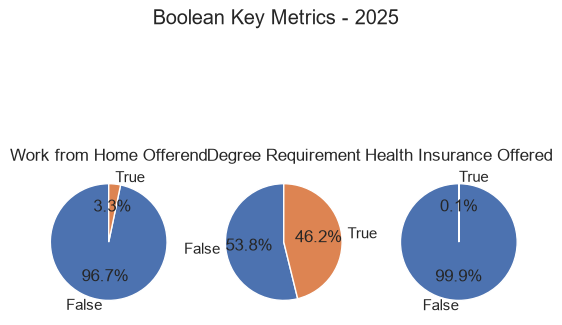

In [28]:
#Three Key Metrics in DACH countries (Remote Work, Degree Requirement, Health Insurance [atypical for Europe]) for data job offerings

dict_columns = {
    "job_work_from_home":"Work from Home Offerend",
    "job_no_degree_mention":"Degree Requirement",
    "job_health_insurance":"Health Insurance Offered"
}

figx, axx = plt.subplots(1,3)

for i,(col,title) in enumerate(dict_columns.items()):
    axx[i].pie(df_DACH[col].value_counts(),labels=["False","True"],autopct="%1.1f%%",startangle=90)
    axx[i].set_title(title)

plt.suptitle("Boolean Key Metrics - 2025")
fig.tight_layout()
plt.show()

In [23]:
#Top 15 companies in DACH countries (incl. Luxembourg) by data job offerings

#Setting both Deutsche Bahn and Deutsche Bahn AG to "Deutsche Bahn" + Setting all mentions of Rocken to "Rocken"
df_DACH.loc[df_DACH["company_name"].str.contains("Deutsche Bahn", na=False, regex=False), "company_name"] = "Deutsche Bahn"
df_DACH.loc[df_DACH["company_name"].str.contains("Rocken", na=False, regex=False), "company_name"] = "Rocken"

df_DACH_plot2 = df_DACH.groupby("company_name").size().sort_values(ascending=False).head(15).to_frame(name="count")

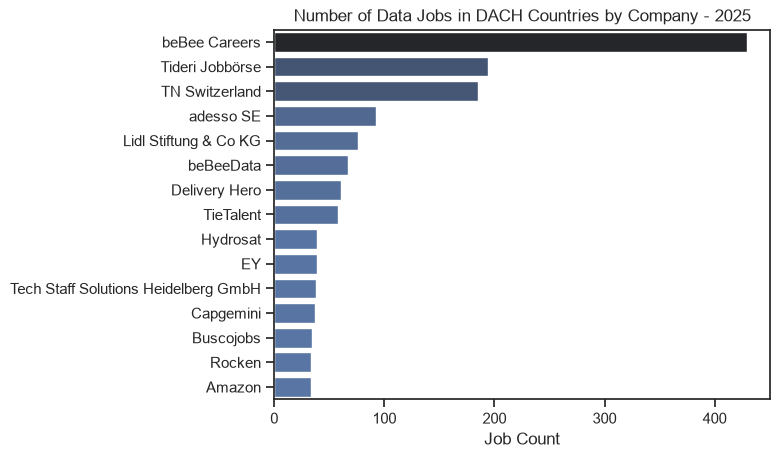

In [26]:
fig, ax = plt.subplots()

sns.set_theme(style="ticks")
sns.barplot(data=df_DACH_plot2,x="count",y="company_name",hue="count",palette="dark:b_r",legend=False)

#sns.despine()
plt.title("Number of Data Jobs in DACH Countries by Company - 2025")
plt.xlabel("Job Count")
plt.ylabel("")
ax.xaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
plt.show()